# Tracking the weak coronal wave of 2025-10-06 with SOLERwave

This notebook traces a weak large-scale coronal (EUV) wave observed on **6 October 2025**
in **SDO/AIA 193 A**, using the [SOLERwave tool](https://github.com/soler-he/SOLERwave_tool)
(Baumgartner-Steinleitner et al. 2026, doi:10.48550/arXiv.2605.23599).

The local AIA level-1.5 files are read **in place** from where they are stored, using the
same discovery pattern as `density_jump_mach.ipynb`. SOLERwave's `create_preprocessed_input`
accepts an external FITS directory, so nothing is copied: it reads the raw frames directly
and writes only the derotated/binned/base-ratio products into the results tree.

Pipeline: preprocess -> great-circle azimuth/radius grid about the source -> octant J-map
quicklook to pick the propagation direction -> segment the sector -> find perturbation peaks
-> trace and fit the wavefront kinematics -> numerical output and figures.

Run it cell by cell; read the propagation direction off the octant plot before cell 8. Set
the two `# <-- EDIT` values (event window and wave origin) first.

## 1. Imports and tool location

In [10]:
import os
import re
import sys
import glob
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.time import parse_time
from sunpy.coordinates import frames
import matplotlib.pyplot as plt

# Local clone of https://github.com/soler-he/SOLERwave_tool
SOLERWAVE_DIR = '/home/mnedal/repos/SOLERwave_tool'
if SOLERWAVE_DIR not in sys.path:
    sys.path.append(SOLERWAVE_DIR)

from SOLERwaves_custom_file_handler import (
    create_folder_structure,
    create_preprocessed_input,
    load_preprocessed_fits,
    create_folder_structure_result,
    create_numerical_output,
    print_parameter_dict,
)
from SOLERwave_find_fit_great_arcs import (
    pixel_to_great_segments,
    find_segments_from_list_staggered,
    distance_uncertainties,
    peak_finding_algorithm,
    wave_tracing_algorithm,
)
# oktant_plot is the octant J-map quicklook shipped with the tool
from SOLERwave_plotting_tool_past_Paper_1 import oktant_plot

## 2. Event configuration

In [37]:
# Local AIA 193 A level-1.5 data, read in place (same layout as density_jump_mach.ipynb)
data_dir = '/home/mnedal/data'
date     = '2025-10-06'
AIA_DIR  = f'{data_dir}/AIA/193A/highres/lv15'

# Event window (inclusive) used to pick the base and end frames
SEQ_START = '2025-10-06T08:40:00'          # <-- EDIT
SEQ_END   = '2025-10-06T09:05:00'          # <-- EDIT

INSTRUMENT_WAVELENGTH = 'AIA_193AA'

# Where SOLERwave writes its derived tree (Preprocesed_Fits, Results). NOT the raw data.
DATA_PATH = f'{data_dir}/SOLERwave'

# Base-ratio spatial binning: 2 = AIA default (better S/N for a weak wave), 1 = native resolution
BINNING = 2

# Wave origin (flare site), Heliographic Stonyhurst, [latitude, longitude] = [N/S, W/E] in deg.
# Read this off the flare location (GOES flare list / AIA wave catalogue).
wave_origin = [10*u.deg, 15*u.deg]           # [lat, lon]

## 3. Discover the frames and build the results tree

Globs the AIA 193 files exactly as `load_channel` does in `density_jump_mach.ipynb`, keeps
those inside the event window, and takes the first/last as the base and end images. The base
time labels the level-0 directory.

In [12]:
def _obs_time(f):
    """AIA observation time from the filename (same parse as density_jump_mach.ipynb)."""
    b = os.path.basename(f)
    m = re.search(r'(\d{4})[_-](\d{2})[_-](\d{2})[T_](\d{2})[:_-]?(\d{2})[:_-]?(\d{2})', b)
    if m:
        Y, Mo, D, h, mi, s = m.groups()
        return parse_time(f'{Y}-{Mo}-{D}T{h}:{mi}:{s}')
    return None

y, mo, d = date.split('-')
all_files = sorted(glob.glob(f'{AIA_DIR}/aia.lev15.193A_{y}_{mo}_{d}T*_lev15*.fits'))
if not all_files:
    raise FileNotFoundError(f'No AIA 193 lv1.5 files under {AIA_DIR} for {date}')

t0, t1 = parse_time(SEQ_START), parse_time(SEQ_END)
window = [f for f in all_files if (t := _obs_time(f)) is not None and t0 <= t <= t1]
if not window:
    raise ValueError(f'No AIA 193 frames in {SEQ_START} .. {SEQ_END}')

base_image_name = os.path.basename(window[0])
end_image_name  = os.path.basename(window[-1])
base_time = _obs_time(window[0]).strftime('%Y-%m-%dT%H:%M:%S')

LVL_0_directory = 'SOLERwave_' + base_time.replace(':', '_') + '-' + INSTRUMENT_WAVELENGTH
print(f'{len(window)} frames in window')
print(f'base : {base_image_name}')
print(f'end  : {end_image_name}')
print(LVL_0_directory)

# Creates DATA_PATH/<LVL_0_directory>/{Input_Fits, Preprocesed_Fits, Results}
path_LVL_0 = create_folder_structure(DATA_PATH, base_time, INSTRUMENT_WAVELENGTH, tool_name='SOLERwave')

125 frames in window
base : aia.lev15.193A_2025_10_06T08_40_04.84Z.image_lev15.fits
end  : aia.lev15.193A_2025_10_06T09_04_52.84Z.image_lev15.fits
SOLERwave_2025-10-06T08_40_04-AIA_193AA
15:35:37 custom_sunpy_file_handler: folder successfully created


## 4. Build the base-ratio sequence the tracer needs

This is **not** L1.5 re-calibration. Your calibrated L1.5 files are the *input*; this step
produces the data product the SOLERwave tracer actually runs on: every frame co-registered to
the base frame (solar-rotation compensated) and divided by the base frame to give **base-ratio**
images. The whole method (octant J-maps, perturbation profiles, peak finding at
`min_peak_height` near 1.0) operates on these ratios, and `load_preprocessed_fits` only reads
the `*_derot_bin_base.fits` / `*_reference.fits` products written here.

`create_preprocessed_input` reads the L1.5 frames straight from `AIA_DIR` (its `fits_path`
argument) with no copy, and processes exactly the files between `base_image_name` and
`end_image_name`, i.e. the event window. Set `BINNING = 1` above to keep native resolution.

In [13]:
create_preprocessed_input(path_LVL_0, AIA_DIR, base_image_name, end_image_name,
                          binning=BINNING, min_exposure_time=1.5, Instrument_Name='aia')

2026-07-10 15:35:41 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.


15:35:41 custom_sunpy_file_handler: binning active 2x2 pixel
15:35:42 custom_sunpy_file_handler: process image: 1 of 124


2026-07-10 15:35:43 - sunpy - WARNING: SunpyUserWarning: Using propagate_with_solar_surface and SphericalScreen together result in loss of off-disk data.
2026-07-10 15:35:43 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-07-10 15:42:05 - astropy - WARNING: VerifyWarning: Verification reported errors:
2026-07-10 15:42:05 - astropy - WARNING: VerifyWarning: HDU 0:
2026-07-10 15:42:05 - astropy - WARNING: VerifyWarning:     'NAXIS1' card at the wrong place (card 27).  Fixed by moving it to the right place (card 3).
2026-07-10 15:42:05 - astropy - WARNING: VerifyWarning:     'NAXIS2' card at the wrong place (card 28).  Fixed by moving it to the right place (card 4).
 [astropy.io.fits.verify]
2026-07-10 15:42:05 - astropy - WARNING: VerifyWarning: Note: astropy.io.fits uses zero-based indexing.



15:42:05 custom_sunpy_file_handler: process image: 2 of 124


2026-07-10 15:42:07 - sunpy - WARNING: SunpyUserWarning: Using propagate_with_solar_surface and SphericalScreen together result in loss of off-disk data.
2026-07-10 15:42:07 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-07-10 15:48:13 - astropy - WARNING: VerifyWarning: Verification reported errors:
2026-07-10 15:48:13 - astropy - WARNING: VerifyWarning: HDU 0:
2026-07-10 15:48:13 - astropy - WARNING: VerifyWarning:     'NAXIS1' card at the wrong place (card 27).  Fixed by moving it to the right place (card 3).
2026-07-10 15:48:13 - astropy - WARNING: VerifyWarning:     'NAXIS2' card at the wrong place (card 28).  Fixed by moving it to the right place (card 4).
 [astropy.io.fits.verify]
2026-07-10 15:48:13 - astropy - WARNING: VerifyWarning: Note: astropy.io.fits uses zero-based indexing.



...

03:39:47 custom_sunpy_file_handler: process image: 123 of 124


2026-07-11 03:39:48 - sunpy - WARNING: SunpyUserWarning: Using propagate_with_solar_surface and SphericalScreen together result in loss of off-disk data.
2026-07-11 03:39:48 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-07-11 03:45:29 - astropy - WARNING: VerifyWarning: Verification reported errors:
2026-07-11 03:45:29 - astropy - WARNING: VerifyWarning: HDU 0:
2026-07-11 03:45:29 - astropy - WARNING: VerifyWarning:     'NAXIS1' card at the wrong place (card 27).  Fixed by moving it to the right place (card 3).
2026-07-11 03:45:29 - astropy - WARNING: VerifyWarning:     'NAXIS2' card at the wrong place (card 28).  Fixed by moving it to the right place (card 4).
 [astropy.io.fits.verify]
2026-07-11 03:45:29 - astropy - WARNING: VerifyWarning: Note: astropy.io.fits uses zero-based indexing.



03:45:29 custom_sunpy_file_handler: process image: 124 of 124


2026-07-11 03:45:29 - sunpy - WARNING: SunpyUserWarning: Using propagate_with_solar_surface and SphericalScreen together result in loss of off-disk data.
2026-07-11 03:45:29 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-07-11 03:51:41 - astropy - WARNING: VerifyWarning: Verification reported errors:
2026-07-11 03:51:41 - astropy - WARNING: VerifyWarning: HDU 0:
2026-07-11 03:51:41 - astropy - WARNING: VerifyWarning:     'NAXIS1' card at the wrong place (card 27).  Fixed by moving it to the right place (card 3).
2026-07-11 03:51:41 - astropy - WARNING: VerifyWarning:     'NAXIS2' card at the wrong place (card 28).  Fixed by moving it to the right place (card 4).
 [astropy.io.fits.verify]
2026-07-11 03:51:41 - astropy - WARNING: VerifyWarning: Note: astropy.io.fits uses zero-based indexing.



03:51:41 custom_sunpy_file_handler: Preprocessed input saved


## 5. Load the preprocessed sequence

In [14]:
(map_data_list, m_base, m_ref_height, r_sun_ref,
 time, exp_time, m_seq_base) = load_preprocessed_fits(path=DATA_PATH,
                                                      LVL_0_directory=LVL_0_directory,
                                                      added_ref_height=0*u.Mm)

print(f'{len(time)} frames, {time[0]} -> {time[-1]}')
print(f'reference radius: {r_sun_ref.to(u.Mm):.1f}')

2026-07-11 03:52:10 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.


03:52:10 load_preprocessed_fits: files loaded
124 frames, 2025-10-06T08:40:16.84 -> 2025-10-06T09:04:52.84
reference radius: 696.0 Mm


## 6. Source coordinate and great-circle grid

`pixel_to_great_segments` assigns every pixel an azimuthal angle `ttheta` (from solar north,
mathematically positive) and a radial angle `aangles_along_arc` (great-circle distance from
the origin). Both are in **radians**.

In [38]:
Flare_coordinates = SkyCoord(wave_origin[1], wave_origin[0],
                             obstime=m_ref_height.date,
                             radius=r_sun_ref,
                             frame=frames.HeliographicStonyhurst).transform_to(m_ref_height.coordinate_frame)

coords, aangles_along_arc, ttheta = pixel_to_great_segments(Flare_coordinates, m_ref_height)
print(f'source (helioprojective): Tx={Flare_coordinates.Tx:.1f}, Ty={Flare_coordinates.Ty:.1f}')

source (helioprojective): Tx=245.7 arcsec, Ty=63.6 arcsec


## 7. Octant plot: pick the propagation direction

Each of the eight J-maps is a distance-time map for a 45 deg sector; a propagating wave shows
up as an oblique ridge of enhanced base-ratio emission. Note the direction (0 deg is solar
north, increasing mathematically positive) of the sector with the clearest ridge. For a weak
wave, look for a faint but coherent diagonal.

14:34:20 Octant Plot: finished


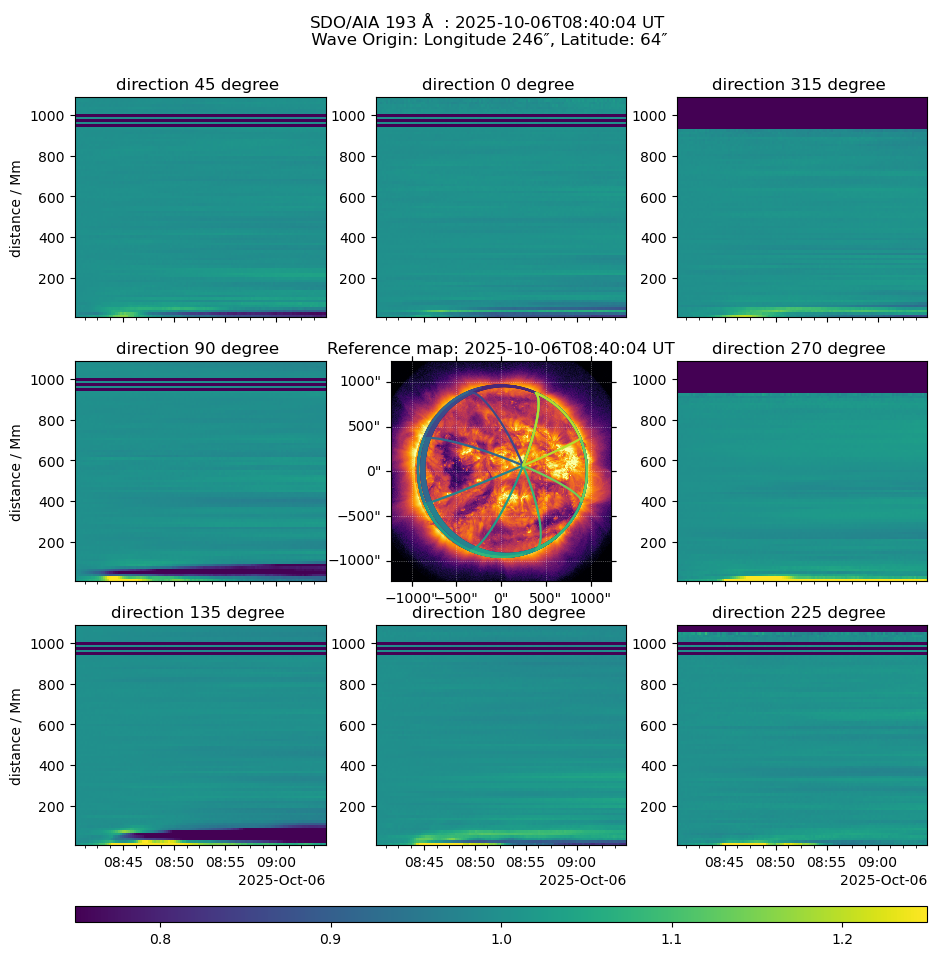

In [39]:
oktant_plot(map_data_list, m_base, Flare_coordinates, r_sun_ref, ttheta, aangles_along_arc, time)

## 8. Define the sector to analyse

In [17]:
# Propagation direction and angular width of the analysed sector (degrees).
# direction = 0 -> solar north; angles increase mathematically positive.
DIRECTION = 90     # <-- EDIT from the octant plot
WIDTH = 30         # sector width; wider averages more pixels (better S/N for a weak wave)

# Radial sampling along the great circle from the origin (degrees)
ARC_MIN_DEG = 0
ARC_MAX_DEG = 40      # ~485 Mm at the solar surface
ARC_STEP_DEG = 0.5

theta_range = np.deg2rad([DIRECTION - WIDTH/2, DIRECTION + WIDTH/2])
angles_along_arc_range = np.deg2rad(np.arange(ARC_MIN_DEG, ARC_MAX_DEG + ARC_STEP_DEG, ARC_STEP_DEG))
print(f'{len(angles_along_arc_range)-1} radial segments in a single {WIDTH} deg sector')

80 radial segments in a single 30 deg sector


## 9. Segment the sector (staggered)

Builds the mean/median/variance perturbation profile per radial segment and time step, with
`times_staggered` sub-steps between segments for finer radial sampling.

In [18]:
parameter_dict = {}
(intensity_mean_stag, intensity_median_stag, intensity_var_stag,
 distance_stag, delta_pixel_distance_stag, base_mask, base_pixel_per_segment,
 parameter_dict) = find_segments_from_list_staggered(theta_range, ttheta,
                                                     angles_along_arc_range, aangles_along_arc,
                                                     map_data_list, r_sun_ref, m_ref_height,
                                                     times_staggered=4,
                                                     calculate_uncertainty=True,
                                                     parameter_dict=parameter_dict)
print(f'perturbation profile shape [distance, theta, time]: {intensity_mean_stag.shape}')

perturbation profile shape [distance, theta, time]: (320, 1, 124)


## 10. Distance uncertainties

In [ ]:
# Note: the 2nd positional argument is the observation-time list (named times_staggered upstream).
delta_distance, segment_pixel_uncertainty, delta_segment = distance_uncertainties(
    distance_stag, time, r_sun_ref, m_ref_height,
    intensity_median_stag, intensity_var_stag,
    delta_distance_pixel=delta_pixel_distance_stag)

## 11. Find perturbation peaks

For a **weak** wave the amplitude threshold matters most: `min_peak_height` is a base-ratio
level (1.10 = a 10% enhancement). Lower it to catch a faint front, then raise it if noise
starts registering as peaks.

In [ ]:
intensity_std_stag = np.sqrt(intensity_var_stag)

(d_peak_mat, d_front_mat, d_trail_mat, d_fitted_peak_mat,
 peak_mat, fitted_peak_mat, front_mat, trail_mat,
 sig_fitted_peak_mat,
 delta_peak_mat, delta_fitted_peak_mat,
 delta_d_peak_mat, delta_d_fitted_peak_mat, delta_d_front_mat, delta_d_trail_mat,
 t_sunpy_sec, max_nr_peaks_vec, max_nr_peaks_const,
 parameter_dict) = peak_finding_algorithm(intensity_mean_stag, intensity_std_stag,
                                          theta_range, distance_stag,
                                          delta_distance, segment_pixel_uncertainty, delta_segment,
                                          time,
                                          max_nr_peaks_const=5,
                                          wavefront_cutof=0.5,
                                          min_peak_height=1.03,   # weak wave: ~3% enhancement
                                          c_closest=0.03,
                                          parameter_dict=parameter_dict)

## 12. Trace and fit the wave

`wave_tracing_algorithm` links peaks across time into waves (velocity gated between
`v_min_step` and `v_max_step`) and applies a linear distance-time fit. It expects a 3d
peak-distance uncertainty, so the asymmetric `delta_d_peak_mat` (lower/upper) is averaged to
a single symmetric estimate.

In [ ]:
# Collapse the asymmetric [2, theta, time, peak] uncertainty to symmetric [theta, time, peak]
d_peak_std_mat = np.nanmean(delta_d_peak_mat, axis=0)

wave_value_dict, parameter_dict = wave_tracing_algorithm(
    d_peak_mat, d_peak_std_mat, t_sunpy_sec, max_nr_peaks_vec,
    peak_tracked=True,
    v_min_step=10,      # km/s
    v_max_step=2000,    # km/s
    min_points_in_wave='default',
    parameter_dict=parameter_dict)

j = 0   # single sector -> theta index 0
n_waves = int(wave_value_dict['nr_of_waves_vec'][j])
print(f'{n_waves} wave(s) traced in the sector')

## 13. Write numerical output

In [ ]:
file_path_dict = create_folder_structure_result(DATA_PATH, LVL_0_directory,
                                                Flare_coordinates, DIRECTION, WIDTH)

instr_dir_width_title_string = f'AIA 193 A  dir {DIRECTION} deg  width {WIDTH} deg'

create_numerical_output(j, intensity_mean_stag, intensity_var_stag, distance_stag,
                        d_peak_mat, d_front_mat, d_trail_mat,
                        peak_mat, front_mat, trail_mat, delta_peak_mat,
                        time, instr_dir_width_title_string, wave_value_dict,
                        file_path_dict=file_path_dict)

print_parameter_dict(parameter_dict, file_path_dict=file_path_dict)
print('Results written under:')
print(file_path_dict['path_LVL_0_Results_0'])

## 14. Figures

Two publication-oriented figures built directly from the returned arrays: the stacked
perturbation profiles (offset by time), and the distance-time kinematics with the linear fit
and speed per traced wave.

In [ ]:
dist_Mm = distance_stag.to_value('Mm')
prof = intensity_mean_stag[:, j, :]          # [distance, time]
n_t = prof.shape[1]
offset = 0.05                                 # vertical offset per frame

fig, ax = plt.subplots(figsize=[7, 9])
colors = plt.cm.viridis(np.linspace(0, 1, n_t))
for t_idx in range(n_t):
    ax.plot(dist_Mm, prof[:, t_idx] + t_idx*offset, color=colors[t_idx], lw=1)

ax.set_xlabel('Distance from source [Mm]')
ax.set_ylabel('Base ratio + time offset')
ax.set_title(f'AIA 193 A perturbation profiles  (dir {DIRECTION} deg)')
ax.margins(x=0)
fig.tight_layout()
plt.show()

In [ ]:
t_dateobj = np.array(time, dtype='datetime64[s]')
t_start = t_dateobj[0]
t_min = (t_dateobj - t_start) / np.timedelta64(1, 's') / 60   # minutes since first frame

fig, ax = plt.subplots(figsize=[7, 5])
for nr_w in range(n_waves):
    ind_vec = wave_value_dict['waves_feature_index'][j][nr_w]
    time_index_vec = np.array(wave_value_dict['waves_time_index'][j][nr_w])

    d = d_peak_mat[j].flatten()[ind_vec]                    # Mm
    d_err = d_peak_std_mat[j].flatten()[ind_vec]            # Mm
    tt_min = t_min[time_index_vec]
    tt_sec = t_sunpy_sec[time_index_vec]

    fit = wave_value_dict['waves_fit'][j][nr_w]             # [slope Mm/s, intercept Mm]
    speed_kms = fit[0] * 1e3

    line = ax.errorbar(tt_min, d, yerr=d_err, fmt='o', ms=4, capsize=2,
                       label=f'wave {nr_w}: {speed_kms:.0f} km/s')
    ax.plot(tt_min, np.polyval(fit, tt_sec), '-', color=line[0].get_color(), lw=1.2)

ax.set_xlabel(f'Minutes since {str(t_start)}')
ax.set_ylabel('Wavefront distance [Mm]')
ax.set_title('Wavefront kinematics (linear fit)')
if n_waves:
    ax.legend()
fig.tight_layout()
plt.show()

## 15. Tuning notes

If the octant plot shows a faint ridge but no wave is traced, work through, in order:
`min_peak_height` (lower toward 1.02 for a weak front), `WIDTH` (wider sector averages more
pixels), `ARC_MAX_DEG`/`ARC_STEP_DEG` (radial coverage and resolution), and
`v_min_step`/`v_max_step` (loosen if the linear gate is rejecting real links). The tool also
ships richer plotting helpers (`plot_perturbation_profiles`, `plot_fit_with_wave_features`,
`plot_timeseries_of_lineplot_and_map`) in `SOLERwave_plotting_tool_past_Paper_1`; see the
tool's own `SOLERwave_Event_Study_Notebook.ipynb` for their argument order in your installed
version.